<a href="https://colab.research.google.com/github/young-suh/ESAA_2026/blob/main/YB_0928(1)_exercises_%E1%84%89%E1%85%B5%E1%84%80%E1%85%A8%E1%84%8B%E1%85%A7%E1%86%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv',sep=',')

### Step 3. Assign it to a variable apple

In [3]:
apple = data

### Step 4.  Check out the type of the columns

In [4]:
apple.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Adj Close,float64


### Step 5. Transform the Date column as a datetime type

In [5]:
apple['Date']=pd.to_datetime(apple['Date'])
apple.dtypes

,0
Date,datetime64[ns]
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Adj Close,float64


### Step 6.  Set the date as the index

In [6]:
apple = apple.set_index('Date')

apple.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 7.  Is there any duplicate dates?

In [9]:
apple.index.duplicated().any()

np.False_

### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [22]:
apple = apple.sort_index(ascending = True)
apple.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-12,28.75,28.87,28.75,28.75,117258400,0.45
1980-12-15,27.38,27.38,27.25,27.25,43971200,0.42
1980-12-16,25.37,25.37,25.25,25.25,26432000,0.39
1980-12-17,25.87,26.00,25.87,25.87,21610400,0.40
1980-12-18,26.63,26.75,26.63,26.63,18362400,0.41


### Step 9. Get the last business day of each month

In [23]:
# 매월 마지막 영업일의 데이터 추출
apple_month = apple.resample('BME').last()  #resample은 특정 기간을 단위로 데이터를 묶음. BME'는 Business Month End의 약자로, 매월 마지막 영업일을 의미. last()를 통해 마지막으로 관측된 행을 선택함.

# 결과 확인
apple_month.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-31,34.25,34.25,34.13,34.13,8937600,0.53
1981-01-30,28.50,28.50,28.25,28.25,11547200,0.44
1981-02-27,26.50,26.75,26.50,26.50,3690400,0.41
1981-03-31,24.75,24.75,24.50,24.50,3998400,0.38
1981-04-30,28.38,28.62,28.38,28.38,3152800,0.44


### Step 10.  What is the difference in days between the first day and the oldest

In [24]:
(apple.index[-1] - apple.index[0]).days
#apple.index[0]: 인덱스의 첫 번째 날짜 (가장 오래된 날짜) , apple.index[-1]: 인덱스의 마지막 날짜 (가장 최근 날짜)
#.days가 날짜 차이를 일 단위의 정수로 반환해줌.

12261

### Step 11.  How many months in the data we have?

In [25]:
# month의 행의 개수로 구하기
apple_month.shape[0]

404

### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

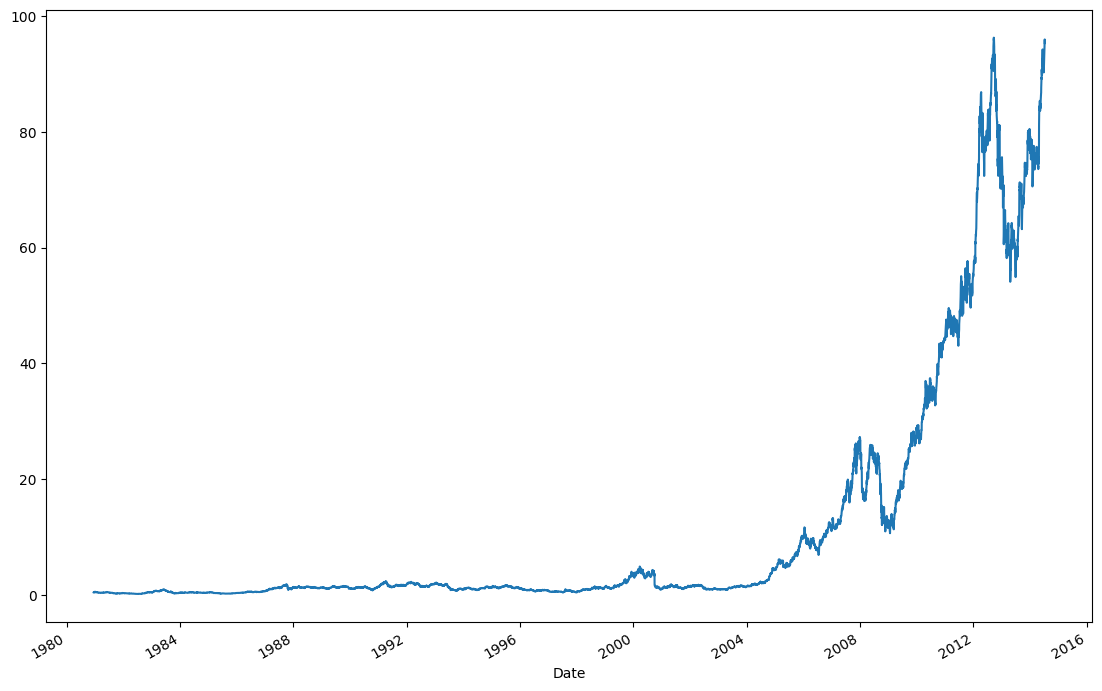

In [26]:
import matplotlib.pyplot as plt

apple['Adj Close'].plot(figsize=(13.5, 9))

plt.show()